# Clarity export loading

Microsoft Clarity exports analytics data as a semi-structured CSV containing multiple embedded report sections rather than a single flat table. The raw export is first loaded without a predefined header structure to preserve all section boundaries and metadata rows for downstream parsing. A msaking is also used to protect client's anonimity.

In [1]:
import pandas as pd

clarity_raw = pd.read_csv(
    '../../data/clarity_analysis_raw.csv',
    header=None
)

print(clarity_raw.head(20))

         0                              1            2    3    4
0      NaN                            NaN          NaN  NaN  NaN
1      NaN                            NaN          NaN  NaN  NaN
2   Metric                       Sessions          NaN  NaN  NaN
3      NaN                 Total sessions         1876  NaN  NaN
4      NaN                   Bot sessions          572  NaN  NaN
5      NaN                            NaN          NaN  NaN  NaN
6   Metric              Pages per session          NaN  NaN  NaN
7      NaN                        Average  1.225479744  NaN  NaN
8      NaN                            NaN          NaN  NaN  NaN
9   Metric                   Scroll depth          NaN  NaN  NaN
10     NaN                        Average        30.64  NaN  NaN
11     NaN                            NaN          NaN  NaN  NaN
12  Metric              Active time spent          NaN  NaN  NaN
13     NaN                    Active time           49  NaN  NaN
14     NaN               

## Automatic section detection

Unlike conventional analytics datasets, Clarity exports contain multiple report blocks inside a single CSV file. Section boundaries are detected programmatically using rows containing the keyword `Metric`, allowing the pipeline to automatically identify embedded report categories such as:

- Sessions
- Browsers
- Top pages
- Referrers
- Smart events
- JavaScript errors
- Performance overview, and few others.

This approach eliminates the need for manual spreadsheet cleaning and creates a reusable parsing workflow for future exports.

In [2]:
section_indices = clarity_raw[
    clarity_raw[0].astype(str).str.contains('Metric', na=False)
].index.tolist()

print(section_indices)

[2, 6, 9, 12, 16, 21, 27, 42, 56, 62, 76, 86, 92]


In [3]:
section_names = []

for idx in section_indices:
    section_name = clarity_raw.iloc[idx, 1]
    section_names.append(section_name)

print(section_names)

['Sessions', 'Pages per session', 'Scroll depth', 'Active time spent', 'Users overview', 'Insights', 'Browsers', 'Top pages', 'Smart events', 'Referrer', 'JavaScript errors', 'Performance overview', 'Bot traffic']


## Section extraction pipeline

After detecting section boundaries, each report block is sliced into its own dataframe dynamically. Empty rows are removed and each extracted section is stored inside a dictionary structure for modular downstream analysis.

This transforms the raw Clarity export into structured analytics tables that can be cleaned, queried, and integrated with GSC and GA4 datasets.

In [4]:
sections = {}

for i, start_idx in enumerate(section_indices):

    section_name = clarity_raw.iloc[start_idx, 1]

    # determine end of section
    if i < len(section_indices) - 1:
        end_idx = section_indices[i + 1]
    else:
        end_idx = len(clarity_raw)

    # slice section
    section_df = clarity_raw.iloc[start_idx + 1:end_idx].copy()

    # remove fully empty rows
    section_df = section_df.dropna(how='all')

    sections[section_name] = section_df.reset_index(drop=True)

print(sections.keys())

dict_keys(['Sessions', 'Pages per session', 'Scroll depth', 'Active time spent', 'Users overview', 'Insights', 'Browsers', 'Top pages', 'Smart events', 'Referrer', 'JavaScript errors', 'Performance overview', 'Bot traffic'])


## Top pages extraction and anonymization

The `Top pages` section was isolated and transformed into a clean dataframe containing page URLs and session counts. Because the repository is public, client-identifying domains are anonymized using a regex-based masking function that preserves URL structure while protecting organizational identity.

Example transformation:

```text
https://original-client-domain.com/blogs/example-page
→
https://client-domain.com/blogs/example-page

In [5]:
import re


CLIENT_ALIAS = 'client-domain.com'

def mask_domain(url):
    if pd.isna(url):
        return url

    return re.sub(
        r'https?://[^/]+',
        f'https://{CLIENT_ALIAS}',
        str(url)
    )

In [6]:
top_pages = sections['Top pages'].copy()

top_pages[1] = top_pages[1].apply(mask_domain)

print(top_pages.head())

     0                                                  1    2    3    4
0  NaN  https://client-domain.com/blogs/simple-compari...  473  NaN  NaN
1  NaN  https://client-domain.com/blogs/aws-in-2026-la...  370  NaN  NaN
2  NaN                         https://client-domain.com/  202  NaN  NaN
3  NaN  https://client-domain.com/blogs/amazon-bedrock...  168  NaN  NaN
4  NaN   https://client-domain.com/blogs/paypal-in-nepal/  133  NaN  NaN


In [7]:
top_pages = sections['Top pages'].copy()

# keep only relevant columns
top_pages = top_pages[[1, 2]]

# rename columns
top_pages.columns = ['page', 'sessions']

# mask client domain
top_pages['page'] = top_pages['page'].apply(mask_domain)

# convert sessions to numeric
top_pages['sessions'] = pd.to_numeric(
    top_pages['sessions'],
    errors='coerce'
)

# remove broken rows
top_pages = top_pages.dropna(subset=['page', 'sessions'])

print(top_pages.head())

                                                page  sessions
0  https://client-domain.com/blogs/simple-compari...       473
1  https://client-domain.com/blogs/aws-in-2026-la...       370
2                         https://client-domain.com/       202
3  https://client-domain.com/blogs/amazon-bedrock...       168
4   https://client-domain.com/blogs/paypal-in-nepal/       133


In [8]:
import pandas as pd
import matplotlib.pyplot as plt


## Extracting key sections
Isolating high-value report blocks: Insights, Smart events, 
Referrer, and Performance overview for downstream analysis.

In [9]:
# Insights
insights = sections['Insights'].copy()
insights.columns = ['_', 'metric', 'sessions', 'pct', '__']
insights = insights.dropna(subset=['metric'])
insights['sessions'] = pd.to_numeric(insights['sessions'], errors='coerce')
insights['pct'] = insights['pct'].str.replace('%', '', regex=False).astype(float)

# Smart events
smart_events = sections['Smart events'].copy()
smart_events.columns = ['_', 'event', 'sessions', 'pct', '__']
smart_events = smart_events.dropna(subset=['event'])
smart_events['sessions'] = pd.to_numeric(smart_events['sessions'], errors='coerce')

# Referrer
referrer = sections['Referrer'].copy()
referrer.columns = ['_', 'source', 'sessions', '__', '___']
referrer = referrer.dropna(subset=['source'])
referrer['sessions'] = pd.to_numeric(referrer['sessions'], errors='coerce')

# Performance
perf = sections['Performance overview'].copy()
perf = perf[[1, 2]].dropna()
perf.columns = ['metric', 'value']
perf = perf.reset_index(drop=True)

# Bot-adjusted baseline
total_sessions = 1876
bot_sessions = 572
real_sessions = total_sessions - bot_sessions

print("Sections extracted.")

Sections extracted.


## Bot traffic assessment
Extracting bot session breakdown to assess data quality and establish a clean session baseline for analysis. Clarity reports total session counts including automated bot traffic. 

Before analysis, the session baseline is adjusted to reflect only human visitors. Bot session counts are extracted from the `Bot traffic` section of the export.

In [10]:
bot_traffic = sections['Bot traffic'].copy()
bot_traffic = bot_traffic[[0, 1]].dropna()
bot_traffic.columns = ['bot_type', 'sessions']
bot_traffic['sessions'] = pd.to_numeric(bot_traffic['sessions'], errors='coerce')
bot_traffic = bot_traffic.dropna(subset=['sessions'])

print("Bot traffic breakdown:")
print(bot_traffic.to_string())
print(f"\nTotal bot sessions: {bot_traffic['sessions'].sum()}")

Bot traffic breakdown:
                           bot_type  sessions
0             webScraperBotSessions      59.0
1       suspiciousDeviceBotSessions     249.0
2      suspiciousNetworkBotSessions     271.0
3  suspiciousInteractionBotSessions     560.0
4             ppcAdFraudBotSessions       0.0
5                 otherBotsSessions       2.0

Total bot sessions: 1141.0


## Adjusted session baseline
Clarity reports 572 unique bot sessions after deduplication across 
bot categories. These are excluded from the analysis baseline to 
ensure metrics reflect genuine human behavior only.

In [11]:
total_sessions = 1876
bot_sessions = 572
real_sessions = total_sessions - bot_sessions

print(f"Total sessions reported:  {total_sessions}")
print(f"Bot sessions (deduplicated): {bot_sessions} ({bot_sessions/total_sessions*100:.1f}%)")
print(f"Real sessions baseline:   {real_sessions} ({real_sessions/total_sessions*100:.1f}%)")

Total sessions reported:  1876
Bot sessions (deduplicated): 572 (30.5%)
Real sessions baseline:   1304 (69.5%)


In [12]:
external_domains = [
    'google', 'bing', 'youtube', 'gemini', 'chatgpt',
    'perplexity', 'copilot', 'goodfirms', 'duckduckgo',
    'instagram', 'facebook', 'samsung', 'mail', 'opera',
    'firefox', 'apple', 'mozilla'
]

def mask_internal(source):
    if pd.isna(source):
        return source
    if not any(ext in source.lower() for ext in external_domains):
        return '[client-site]'
    return source

referrer['source'] = referrer['source'].apply(mask_internal)

print(f"Real sessions baseline: {real_sessions} ({real_sessions/total_sessions*100:.1f}% of total)\n")
print("Insights:\n", insights[['metric', 'sessions', 'pct']].to_string())
print("\nSmart events:\n", smart_events[['event', 'sessions']].to_string())
print("\nReferrer (cleaned):\n", referrer[['source', 'sessions']].to_string())
print("\nPerformance:\n", perf.to_string())

Real sessions baseline: 1304 (69.5% of total)

Insights:
                 metric  sessions   pct
0          Rage clicks         0  0.00
1           Dead click         8  0.43
2  Excessive scrolling         1  0.05
3     Quick back click        71  3.78

Smart events:
             event  sessions
0      Contact us        40
1  Outbound click        29
2     Submit form         4
3       Show more         3

Referrer (cleaned):
                                      source  sessions
0                              www.bing.com       506
1                            www.google.com       431
2                             [client-site]       231
3                         gemini.google.com        55
4                               chatgpt.com        17
5                           www.youtube.com        13
6                           mail.google.com        12
7                     copilot.microsoft.com        10
8                         www.perplexity.ai        10
9   com.google.android.google

## Key findings

### 1. Traffic source analysis
Breaking down where Clarity sessions originate, separating 
search engines, AI referrers, and other sources.

In [13]:
# Categorize referrers
def categorize_source(source):
    source = str(source).lower()
    if 'bing' in source:
        return 'Bing Search'
    elif 'google.com' in source and 'gemini' not in source and 'mail' not in source:
        return 'Google Search'
    elif source == '[client-site]':
        return 'Internal'
    elif any(ai in source for ai in ['gemini', 'chatgpt', 'perplexity', 'copilot']):
        return 'AI Referrer'
    elif 'youtube' in source or 'mail' in source:
        return 'Google Properties'
    else:
        return 'Other'

referrer['category'] = referrer['source'].apply(categorize_source)

category_summary = referrer.groupby('category')['sessions'].sum().sort_values(ascending=False)

print("Traffic source categories:")
print(category_summary)
print(f"\nAI referrers total: {referrer[referrer['category'] == 'AI Referrer']['sessions'].sum()} sessions")

Traffic source categories:
category
Bing Search          506
Google Search        431
Internal             231
AI Referrer           92
Google Properties     25
Other                 24
Name: sessions, dtype: int64

AI referrers total: 92 sessions


### Traffic source analysis
Categorizing referrer sources into search engines, AI platforms, 
internal traffic, and other channels to understand how users 
are discovering the site.

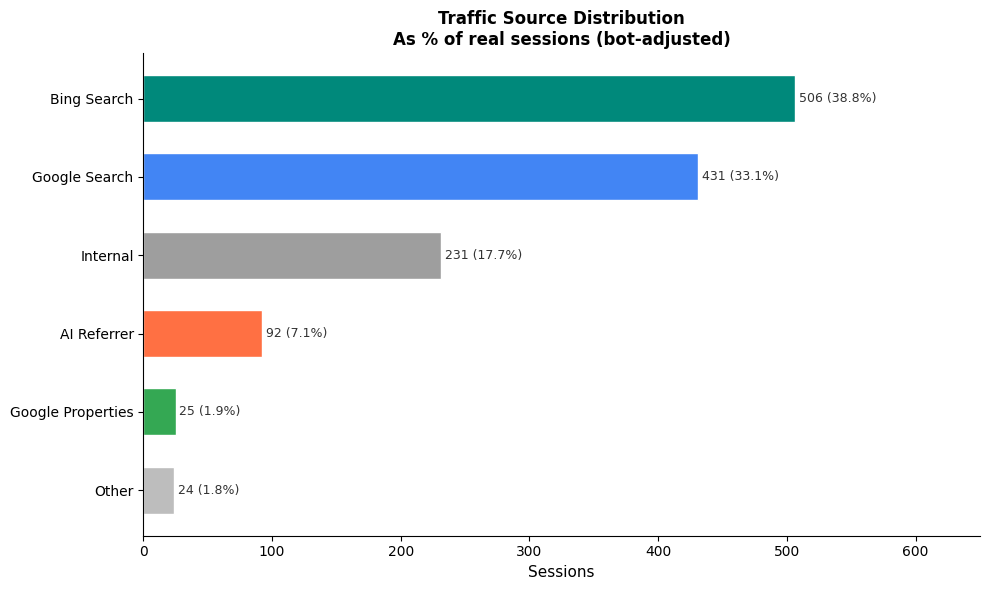

Chart saved.


In [14]:
import os
os.makedirs('../output-clarity/chart', exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Bing Search': '#00897B',
    'Google Search': '#4285F4',
    'Internal': '#9E9E9E',
    'AI Referrer': '#FF7043',
    'Google Properties': '#34A853',
    'Other': '#BDBDBD'
}

bars = ax.barh(
    category_summary.index[::-1],
    category_summary.values[::-1],
    color=[colors.get(c, '#BDBDBD') for c in category_summary.index[::-1]],
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, category_summary.values[::-1]):
    ax.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({val/real_sessions*100:.1f}%)',
        va='center',
        fontsize=9,
        color='#333333'
    )

ax.set_xlabel('Sessions', fontsize=11)
ax.set_title(
    'Traffic Source Distribution\nAs % of real sessions (bot-adjusted)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlim(0, 650)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-clarity/chart/traffic_sources.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Behavioral signals
Analyzing Clarity insight flags and smart events to understand 
how users interact with content after arriving.

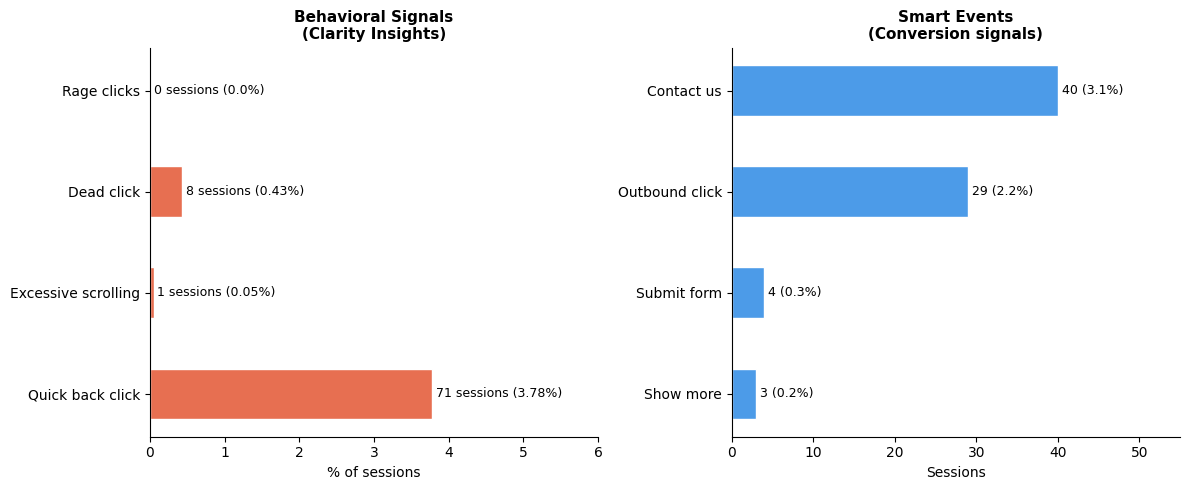

Chart saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Insights chart
axes[0].barh(
    insights['metric'][::-1],
    insights['pct'][::-1],
    color='#E76F51',
    edgecolor='white',
    height=0.5
)
for i, (val, pct) in enumerate(zip(insights['sessions'][::-1], insights['pct'][::-1])):
    axes[0].text(
        pct + 0.05,
        i,
        f'{val} sessions ({pct}%)',
        va='center',
        fontsize=9
    )
axes[0].set_xlabel('% of sessions', fontsize=10)
axes[0].set_title('Behavioral Signals\n(Clarity Insights)', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 6)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Smart events chart
axes[1].barh(
    smart_events['event'][::-1],
    smart_events['sessions'][::-1],
    color='#4C9BE8',
    edgecolor='white',
    height=0.5
)
for i, val in enumerate(smart_events['sessions'][::-1]):
    axes[1].text(
        val + 0.5,
        i,
        f'{val} ({val/real_sessions*100:.1f}%)',
        va='center',
        fontsize=9
    )
axes[1].set_xlabel('Sessions', fontsize=10)
axes[1].set_title('Smart Events\n(Conversion signals)', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, 55)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-clarity/chart/behavioral_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Top pages: Clarity vs GA4
Comparing Clarity session counts with GA4 sessions per page 
to identify behavioral consistency across tools.

In [16]:
# Load GA4 for comparison
ga4_compare = pd.read_csv('../../data/ga4_landing_page.csv', skiprows=9)
ga4_compare.columns = ga4_compare.columns.str.strip()
ga4_compare = ga4_compare.rename(columns={'Landing page': 'Page'})
ga4_compare['Page'] = ga4_compare['Page'].str.rstrip('/')

# Clean top pages
top_pages['page_clean'] = (
    top_pages['page']
    .str.replace(r'https?://[^/]+', '', regex=True)
    .str.rstrip('/')
)

# Merge with GA4
combined = top_pages.merge(
    ga4_compare[['Page', 'Sessions', 'Average engagement time per session']],
    left_on='page_clean',
    right_on='Page',
    how='left'
)

combined = combined.rename(columns={
    'sessions': 'clarity_sessions',
    'Sessions': 'ga4_sessions',
    'Average engagement time per session': 'engagement_time'
})

combined['label'] = combined['page_clean'].str.replace('/blogs/', '', regex=False).str.replace('/', '', regex=False)

print(combined[['label', 'clarity_sessions', 'ga4_sessions', 'engagement_time']].to_string())

                                   label  clarity_sessions  ga4_sessions  engagement_time
0   simple-comparison-of-zoom-vs-discord               473           338        14.482249
1    aws-in-2026-latest-services-updates               370           592        17.701014
2                                                      202           572        37.127622
3   amazon-bedrock-aws-ai-platform-guide               168           232         7.564655
4                        paypal-in-nepal               133           257        29.626459
5    zoom-not-working-troubleshoot-guide               119           140        36.800000
6                             contact-us                65            36        11.027778
7         complete-guide-to-aws-database                47            78         6.948718
8     zoom-camera-issues-easy-detect-fix                47            42        21.738095
9                                 career                44            39        14.256410
10     fre

### Clarity vs GA4 session comparison
Divergence between tools reveals differences in how each 
platform counts and attributes sessions.

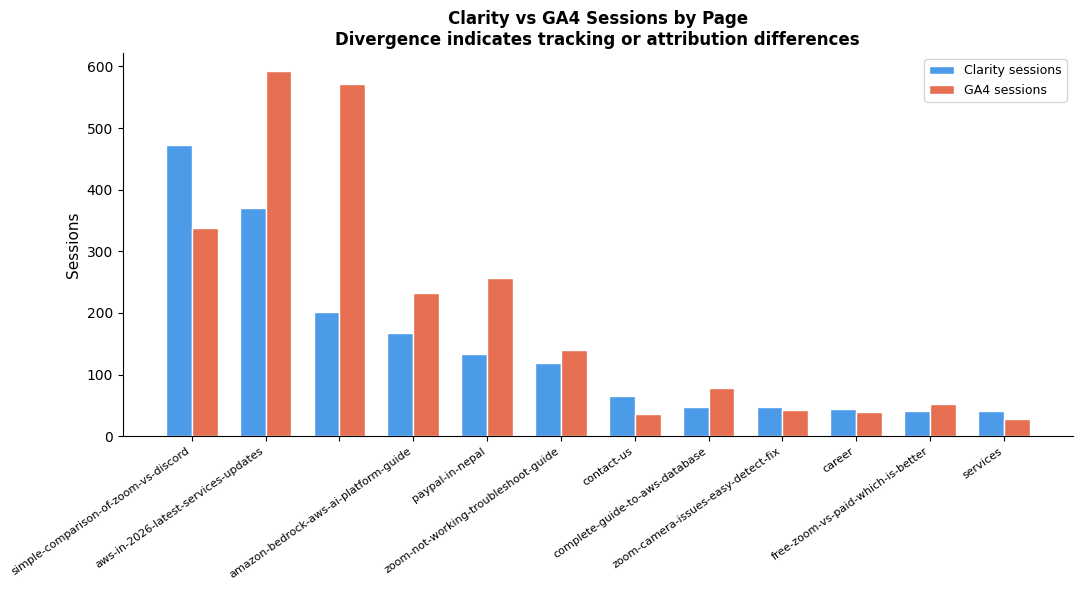

Chart saved.


In [17]:
plot_data = combined.dropna(subset=['ga4_sessions']).copy()

fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(plot_data))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    plot_data['clarity_sessions'],
    width,
    label='Clarity sessions',
    color='#4C9BE8',
    edgecolor='white'
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    plot_data['ga4_sessions'],
    width,
    label='GA4 sessions',
    color='#E76F51',
    edgecolor='white'
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data['label'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Sessions', fontsize=11)
ax.set_title(
    'Clarity vs GA4 Sessions by Page\nDivergence indicates tracking or attribution differences',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-clarity/chart/clarity_vs_ga4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Web performance analysis
Evaluating Core Web Vitals scores from Clarity to assess 
technical performance impact on user experience and rankings.

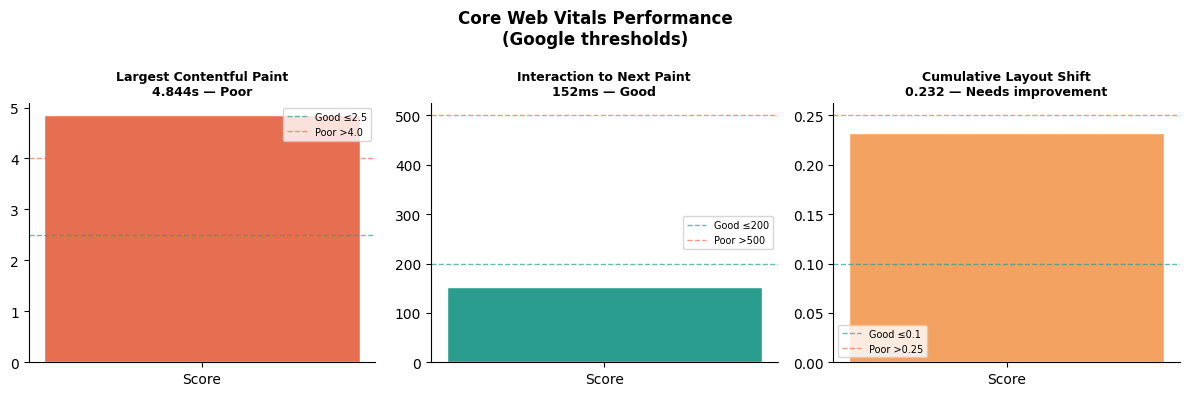

Chart saved.


In [18]:
# Performance thresholds (Google standards)
thresholds = {
    'LCP (Largest Contentful Paint)': {'good': 2.5, 'poor': 4.0, 'unit': 's', 'value': 4.844},
    'INP (Interaction to Next Paint)': {'good': 200, 'poor': 500, 'unit': 'ms', 'value': 152},
    'CLS (Cumulative Layout Shift)': {'good': 0.1, 'poor': 0.25, 'unit': '', 'value': 0.232},
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (metric, data) in zip(axes, thresholds.items()):
    val = data['value']
    good = data['good']
    poor = data['poor']

    if val <= good:
        color = '#2A9D8F'
        status = 'Good'
    elif val <= poor:
        color = '#F4A261'
        status = 'Needs improvement'
    else:
        color = '#E76F51'
        status = 'Poor'

    ax.bar(['Score'], [val], color=color, width=0.4, edgecolor='white')
    ax.axhline(y=good, color='#2A9D8F', linestyle='--', linewidth=1, alpha=0.7, label=f'Good ≤{good}')
    ax.axhline(y=poor, color='#E76F51', linestyle='--', linewidth=1, alpha=0.7, label=f'Poor >{poor}')
    ax.set_title(f'{metric.split("(")[1].rstrip(")")}\n{val}{data["unit"]} — {status}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Core Web Vitals Performance\n(Google thresholds)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output-clarity/chart/core_web_vitals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Session quality metrics
Evaluating scroll depth and active vs total time to understand 
how deeply users engage with content.

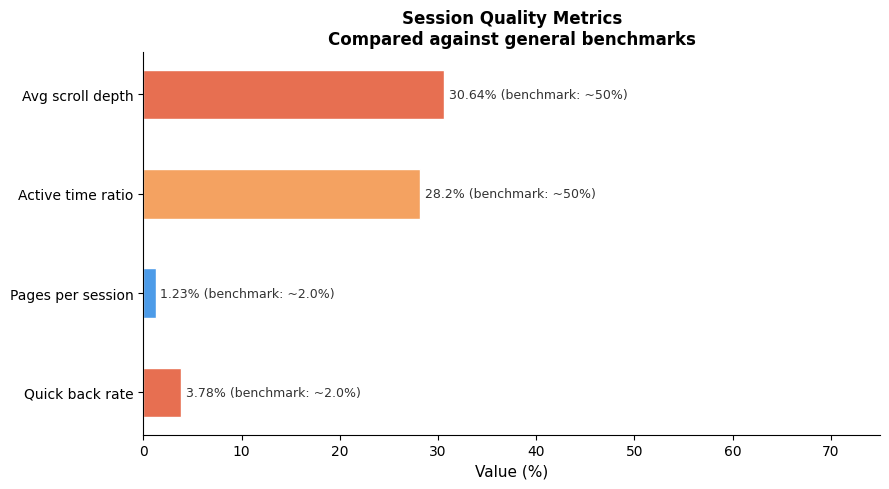

Chart saved.


In [19]:
metrics = {
    'Avg scroll depth': 30.64,
    'Active time ratio': round(49/174*100, 1),
    'Pages per session': 1.23,
    'Quick back rate': 3.78
}

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E76F51', '#F4A261', '#4C9BE8', '#E76F51']
bars = ax.barh(
    list(metrics.keys())[::-1],
    list(metrics.values())[::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.5
)

benchmarks = {
    'Avg scroll depth': 50,
    'Active time ratio': 50,
    'Pages per session': 2.0,
    'Quick back rate': 2.0
}

for bar, (metric, val) in zip(bars, list(metrics.items())[::-1]):
    benchmark = benchmarks[metric]
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val}% (benchmark: ~{benchmark}%)',
        va='center',
        fontsize=9,
        color='#333333'
    )

ax.set_xlabel('Value (%)', fontsize=11)
ax.set_title(
    'Session Quality Metrics\nCompared against general benchmarks',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlim(0, 75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-clarity/chart/session_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")